In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import random
import time
import json
import os

from IPython.display import display
import matplotlib
matplotlib.get_backend()


'widget'

In [24]:
# Enable interactive matplotlib backend for Jupyter
# Run this cell first to enable click interactions
# If clicking doesn't work, try: pip install ipympl, then restart kernel
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
    print("Using matplotlib widget backend (interactive)")
except:
    try:
        get_ipython().run_line_magic('matplotlib', 'notebook')
        print("Using matplotlib notebook backend (interactive)")
    except:
        get_ipython().run_line_magic('matplotlib', 'inline')
        print("Using inline backend (limited interactivity)")
        print("For full interactivity, install: pip install ipympl")


Using matplotlib widget backend (interactive)


In [25]:
# ---- Correct MLP with BN + Dropout (same as training) ----
class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=512, num_layers=6):
        super().__init__()
        in_dim = k * 3

        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden))

        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.Dropout(0.1))

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ---- Updated loader ----
def load_integrator_model(model_path, device="cpu"):
    device = torch.device(device)

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    k = checkpoint['k']
    hidden = checkpoint['hidden']
    num_layers = checkpoint.get('num_layers', 6)

    model = MLPIntegrator(k=k, hidden=hidden, num_layers=num_layers).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = {
        'k': k,
        'R': checkpoint['R'],
        'hidden': hidden,
        'num_layers': num_layers,
        'u_scale': checkpoint['u_scale'],
        'Nx': checkpoint['Nx'],
        'Nt': checkpoint['Nt'],
    }

    print(f"Model loaded: k={k}, R={config['R']}, hidden={hidden}, num_layers={num_layers}")
    print(f"u_scale={config['u_scale']:.6e}")

    return model, config


In [26]:
def build_bc_mask(Nt, Nx):
    is_bc = np.zeros((Nt, Nx), dtype=bool)
    is_bc[:, 0] = True
    is_bc[:, Nx-1] = True
    return is_bc


def candidates_from_interior_ball(visited, is_bc, R):
    """
    Generate candidate points (unvisited) within a circular radius
    of any visited interior point.

    visited: bool (Nt, Nx)
    is_bc: bool (Nt, Nx)
    R: integer radius in index space
    """
    Nt, Nx = visited.shape
    interior = np.argwhere(visited & (~is_bc))
    cand = set()

    for (t0, x0) in interior:
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        for t in range(t_min, t_max + 1):
            dt = t - t0
            dt2 = dt * dt
            if dt2 > R * R:
                continue

            for x in range(x_min, x_max + 1):
                if visited[t, x]:
                    continue
                dx = x - x0
                if dt2 + dx * dx <= R * R:
                    cand.add((t, x))

    return np.array(list(cand), dtype=int), interior
def nearest_k_global(visited_pts, center, k=5):
    """
    Select k nearest visited points to 'center' using circular metric.

    visited_pts: ndarray of shape (M,2) containing (t,x)
    center: tuple (t0, x0)
    k: number of neighbors
    """
    if len(visited_pts) == 0:
        return np.empty((0, 2), dtype=int)

    t0, x0 = center
    dt = visited_pts[:,0] - t0
    dx = visited_pts[:,1] - x0
    d = dt*dt + dx*dx  # circular metric

    # sort & take first k (handles case len < k)
    idx = np.argsort(d)[:k]
    return visited_pts[idx]
def activate_bc_from_balls(visited, is_bc, R):
    Nt, Nx = visited.shape
    interior = np.argwhere(visited & (~is_bc))

    for (t0, x0) in interior:
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        for t in range(t_min, t_max + 1):
            dt2 = (t - t0)**2
            if dt2 > R*R:
                continue
            for x in range(x_min, x_max + 1):
                if is_bc[t,x]:
                    dx = x - x0
                    if dt2 + dx*dx <= R*R:
                        visited[t,x] = True


In [27]:
def build_features_for_model(visited_pts, sampled, u_values,
                             R, u_scale, k=5, model_k=None):
    """
    Build features for neural integrator (Scheme-B format).
    
    visited_pts: array (N,2) of visited (t,x)
    sampled: tuple (t,x) to predict
    u_values: dict with {(t,x): u}
    R: circular radius used in rollout & training
    u_scale: scaling for u
    k: number of neighbors for rollout
    model_k: if model expects different k (else None)
    
    returns:
       feats: shape (model_k*3,)
       neigh: (k,2) neighbors actually used
    """
    if model_k is None:
        model_k = k

    # ---- nearest-k from all visited ----
    neigh = nearest_k_global(visited_pts, sampled, k=k)

    # ---- pad if fewer than k (early stage rollout) ----
    if len(neigh) < k:
        pad = np.zeros((k,2), dtype=int)
        if len(neigh) > 0:
            pad[:len(neigh)] = neigh
            pad[len(neigh):] = neigh[-1]   # repeat last
        neigh = pad
    else:
        neigh = neigh[:k]

    # ---- Scheme-B features ----
    t0, x0 = sampled
    feats = []
    for (tn, xn) in neigh:
        dt_scaled = (t0 - tn) / R
        dx_scaled = (x0 - xn) / R
        u_scaled = u_values.get((int(tn), int(xn)), 0.0) / u_scale
        feats.append([dt_scaled, dx_scaled, u_scaled])

    # ---- pad/truncate for model_k ----
    if model_k > k:
        feats.extend([[0.0,0.0,0.0]]*(model_k-k))
    elif model_k < k:
        feats = feats[:model_k]

    feats = np.array(feats, dtype=np.float32).reshape(-1)
    return feats, neigh


In [28]:
try:
    import mplcursors

    def visualize_rollout_interactive_simple(visited, u_values, history, ground_truth_data, R, config=None):
        """
        Simple interactive visualization using mplcursors.
        Hover shows error, prediction, neighbors, etc.
        """
        Nt, Nx = visited.shape
        
        fig, ax = plt.subplots(figsize=(12, 8))

        # Gather points
        visited_pts = np.array(list(u_values.keys()))
        history_dict = {tuple(h['sampled']): h for h in history}

        ic_bc_pts = []
        pred_pts = []
        pred_vals = []

        for pt in visited_pts:
            pt_tuple = tuple(pt)
            if pt_tuple in history_dict:
                pred_pts.append(pt_tuple)
                pred_vals.append(u_values[pt_tuple])
            else:
                ic_bc_pts.append(pt_tuple)

        # Plot IC/BC
        if len(ic_bc_pts) > 0:
            ic_bc_arr = np.array(ic_bc_pts)
            ax.scatter(
                ic_bc_arr[:,1], ic_bc_arr[:,0],
                s=20, c='gray', alpha=0.5,
                label='IC/BC', zorder=1
            )

        # Plot predicted interior
        if len(pred_pts) > 0:
            pred_pts_arr = np.array(pred_pts)
            pred_vals_arr = np.array(pred_vals)

            scatter = ax.scatter(
                pred_pts_arr[:,1], pred_pts_arr[:,0],
                c=pred_vals_arr, s=40,
                cmap='viridis', alpha=0.8,
                edgecolors='black', linewidth=0.5,
                label='Predicted', zorder=2, picker=True
            )
            plt.colorbar(scatter, ax=ax, label='Predicted u value')

            # Hover tooltips (error, neighbors...)
            cursor = mplcursors.cursor(scatter, hover=True)

            @cursor.connect("add")
            def on_add(sel):
                idx = sel.target.index
                pt = tuple(pred_pts_arr[idx])
                h = history_dict.get(pt, None)
                if h is not None:
                    pred = h['prediction']
                    true = h['ground_truth']
                    err = pred - true
                    neigh = h['neighbors']
                    sel.annotation.set_text(
                        f"Point: {pt}\n"
                        f"Pred: {pred:.4f}\n"
                        f"True: {true:.4f}\n"
                        f"Error: {err:.4f}\n"
                        f"Neighbors: {len(neigh)}"
                    )
                else:
                    sel.annotation.set_text(f"{pt}")

        ax.set_xlabel('x (space)')
        ax.set_ylabel('t (time)')
        ax.set_title('Rollout prediction (hover for details)')
        ax.set_aspect('auto')
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("mplcursors available - interactive visualization ready")

except ImportError:
    print("mplcursors not available. Install with: pip install mplcursors")


mplcursors available - interactive visualization ready


In [29]:
def visualize_rollout_simple(visited, u_values, history, ground_truth_data, R, config=None):
    """
    Simple non-interactive visualization of rollout results.
    """
    Nt, Nx = visited.shape

    fig, ax = plt.subplots(figsize=(12, 8))

    visited_pts = np.array(list(u_values.keys()))
    history_dict = {tuple(h['sampled']): h for h in history}

    ic_bc_pts = []
    pred_pts = []
    pred_vals = []

    for pt in visited_pts:
        pt_t = tuple(pt)
        if pt_t in history_dict:
            pred_pts.append(pt_t)
            pred_vals.append(u_values[pt_t])
        else:
            ic_bc_pts.append(pt_t)

    print(f"Plotting: {len(ic_bc_pts)} IC/BC points, {len(pred_pts)} predicted points")

    # ---- IC + BC points ----
    if len(ic_bc_pts) > 0:
        ic_bc_arr = np.array(ic_bc_pts)
        ax.scatter(
            ic_bc_arr[:,1], ic_bc_arr[:,0],
            s=20, c='gray', alpha=0.5,
            label='IC/BC', zorder=1
        )

    # ---- Predicted points ----
    if len(pred_pts) > 0:
        pred_pts_arr = np.array(pred_pts)
        pred_vals_arr = np.array(pred_vals)

        scatter = ax.scatter(
            pred_pts_arr[:,1], pred_pts_arr[:,0],
            c=pred_vals_arr, s=40,
            cmap='viridis', alpha=0.8,
            edgecolors='black', linewidth=0.5,
            label='Predicted', zorder=2
        )
        plt.colorbar(scatter, ax=ax, label='Predicted u value')
    else:
        ax.text(
            0.5, 0.5,
            'No predicted interior points to display',
            transform=ax.transAxes,
            ha='center', va='center', fontsize=14
        )

    ax.set_xlabel('x (space)')
    ax.set_ylabel('t (time)')
    ax.set_title('Rollout Results — Predicted Interior Points')
    ax.set_aspect('auto')

    if len(pred_pts) > 0 or len(ic_bc_pts) > 0:
        ax.legend()

    plt.tight_layout()

    # For Jupyter
    display(fig)

    print(f"\n✓ Displayed {len(pred_pts)} predicted points and {len(ic_bc_pts)} IC/BC points")

    return fig, ax


# LOOK HERE!

In [30]:
def visualize_error_propagation(visited, u_values, history, ground_truth_data):
    """
    Visualize how prediction errors propagate over time.

    Uses the 'history' list that rollout_with_model produced.
    Shows:
      1. Mean error vs time (with std)
      2. Absolute error stats vs time (mean / min / max)
      3. Number of predictions per time step
      4. Heatmap of abs(error) distribution over time
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import numpy.ma as ma

    errors_by_time = {}
    abs_errors_by_time = {}

    # ---- collect errors per time step ----
    for h in history:
        t, x = h['sampled']
        pred = h['prediction']
        true = h['ground_truth']
        err = pred - true
        aerr = abs(err)

        if t not in errors_by_time:
            errors_by_time[t] = []
            abs_errors_by_time[t] = []

        errors_by_time[t].append(err)
        abs_errors_by_time[t].append(aerr)

    if len(errors_by_time) == 0:
        print("No predictions found in history!")
        return None, None

    times = sorted(errors_by_time.keys())
    mean_errors     = [np.mean(errors_by_time[t])      for t in times]
    std_errors      = [np.std(errors_by_time[t])       for t in times]
    mean_abs_errors = [np.mean(abs_errors_by_time[t])  for t in times]
    max_abs_errors  = [np.max(abs_errors_by_time[t])   for t in times]
    min_abs_errors  = [np.min(abs_errors_by_time[t])   for t in times]
    counts          = [len(errors_by_time[t])          for t in times]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) mean error vs time
    ax1 = axes[0, 0]
    ax1.plot(times, mean_errors, 'b-', linewidth=2, marker='o', markersize=4, label='Mean Error')
    lower = [m - s for m, s in zip(mean_errors, std_errors)]
    upper = [m + s for m, s in zip(mean_errors, std_errors)]
    ax1.fill_between(times, lower, upper, alpha=0.3, color='blue', label='±1 Std')
    ax1.axhline(0.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Time (t)')
    ax1.set_ylabel('Error (pred - true)')
    ax1.set_title('Mean Error Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2) abs error stats vs time (log scale)
    ax2 = axes[0, 1]
    ax2.plot(times, mean_abs_errors, 'r-', linewidth=2, marker='o', markersize=4, label='Mean |Error|')
    ax2.plot(times, max_abs_errors,  'r--', linewidth=1.5, alpha=0.7, label='Max |Error|')
    ax2.plot(times, min_abs_errors,  'r:',  linewidth=1.5, alpha=0.7, label='Min |Error|')
    ax2.fill_between(times, min_abs_errors, max_abs_errors, alpha=0.2, color='red')
    ax2.set_xlabel('Time (t)')
    ax2.set_ylabel('Absolute Error')
    ax2.set_title('Absolute Error Statistics Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    # 3) prediction counts vs time
    ax3 = axes[1, 0]
    ax3.bar(times, counts, alpha=0.6, color='green', edgecolor='black', linewidth=0.5)
    ax3.set_xlabel('Time (t)')
    ax3.set_ylabel('Number of Predictions')
    ax3.set_title('Prediction Density Over Time')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4) heatmap of abs(error) distribution vs time
    ax4 = axes[1, 1]
    all_abs_errors = np.array([a for t in times for a in abs_errors_by_time[t]])
    if all_abs_errors.size > 0:
        # avoid log10(0); clamp very small errors
        eps = 1e-12
        amin = max(all_abs_errors.min(), eps)
        amax = max(all_abs_errors.max(), amin + eps)
        error_bins = np.logspace(np.log10(amin), np.log10(amax), 20)
        error_hist = np.zeros((len(times), len(error_bins)-1))

        for i, t in enumerate(times):
            hist, _ = np.histogram(abs_errors_by_time[t], bins=error_bins)
            error_hist[i, :] = hist

        im = ax4.imshow(
            error_hist.T,
            aspect='auto',
            origin='lower',
            cmap='YlOrRd',
            interpolation='nearest'
        )
        ax4.set_xlabel('Time (t)')
        ax4.set_ylabel('Error magnitude bin (log scale)')
        ax4.set_title('Error Distribution Over Time')

        # reasonable x-ticks
        step = max(1, len(times)//10)
        ax4.set_xticks(range(0, len(times), step))
        ax4.set_xticklabels([times[i] for i in range(0, len(times), step)])
        plt.colorbar(im, ax=ax4, label='Count')

    plt.tight_layout()
    plt.show()

    # ---- summary stats ----
    print("\n" + "="*60)
    print("ERROR PROPAGATION SUMMARY")
    print("="*60)

    all_errors = np.array([e for t in times for e in errors_by_time[t]])
    all_abs_flat = np.abs(all_errors)

    print(f"Total time steps with predictions: {len(times)}")
    print(f"Time range: t={min(times)} to t={max(times)}")
    print("\nOverall Statistics:")
    print(f"  Mean error:   {all_errors.mean():.6f}")
    print(f"  Std error:    {all_errors.std():.6f}")
    print(f"  Mean |error|: {all_abs_flat.mean():.6f}")
    print(f"  Max  |error|: {all_abs_flat.max():.6f}")
    print(f"  RMSE:         {np.sqrt((all_errors**2).mean()):.6f}")

    if len(times) > 1:
        coeffs = np.polyfit(times, mean_abs_errors, 1)
        trend = "increasing" if coeffs[0] > 0 else "decreasing"
        n10 = max(1, len(times)//10)
        early = np.mean(mean_abs_errors[:n10])
        late  = np.mean(mean_abs_errors[-n10:])

        print("\nError Trend:")
        print(f"  Mean |error| trend: {trend} (slope: {coeffs[0]:.2e} per time step)")
        print(f"  Early time (first 10%): mean |error| = {early:.6f}")
        print(f"  Late time  (last  10%): mean |error| = {late:.6f}")

    print("="*60 + "\n")

    return fig, axes


In [31]:
# Generate ground truth data (same as training)
def diffusion_solver_dirichlet(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=2000):
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap
        u[0] = 0.0
        u[-1] = 0.0
        traj.append(u.copy())
    return np.stack(traj)

def generate_diffusion_data(Nx=500, nu=0.01, dt=1e-4, n_steps=2000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)
    u0 = np.sin(2*np.pi * x)
    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data

x, data = generate_diffusion_data(Nx=500, nu=0.01, dt=1e-4, n_steps=20000)
print(f"Data shape: {data.shape}")


Data shape: (20001, 500)


In [32]:
def rollout_with_model(
    model,
    ground_truth_data,
    R=None,
    k=None,
    u_scale=None,
    model_config=None,
    max_iterations=1000,
    device="cpu",
    seed=None,
):
    """
    Roll out the neural integrator on a fixed ground-truth diffusion trajectory.

    Args
    ----
    model : torch.nn.Module
        Trained MLPIntegrator.
    ground_truth_data : np.ndarray
        Array of shape (Nt, Nx) with true u(t, x).
    R : int, optional
        Rollout radius in index space (for selecting candidates / scaling dt,dx).
    k : int, optional
        Number of neighbors used in the rollout feature construction.
    u_scale : float, optional
        Scale factor used to normalize u in features (same as training).
    model_config : dict, optional
        Config returned by `load_integrator_model`. If provided, we use
        its 'R', 'k', and 'u_scale' as defaults for the above.
    max_iterations : int
        Maximum number of interior predictions to perform.
    device : str
        Torch device.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    visited : np.ndarray (bool, shape (Nt, Nx))
        Mask of points with known or predicted values.
    u_values : dict
        Mapping (t, x) -> u(t, x) (float), including IC/BC and predictions.
    history : list of dict
        Each element contains:
          - 'sampled': [t, x]
          - 'neighbors': list[[tn, xn], ...]
          - 'prediction': float
          - 'ground_truth': float
    metrics : dict
        Summary metrics:
          - 'total_iterations'
          - 'coverage'
          - 'visited_count'
          - 'total_points'
          - 'mse'
          - 'rmse'
    """
    device = torch.device(device)

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        if torch.cpu.is_available():
            torch.cpu.manual_seed_all(seed)

    # Ensure numpy array
    ground_truth_data = np.asarray(ground_truth_data, dtype=np.float32)
    Nt, Nx = ground_truth_data.shape

    # Fill from model_config if provided
    if model_config is not None:
        if R is None:
            R = int(model_config.get("R", 10))
        if k is None:
            k = int(model_config.get("k", 5))
        if u_scale is None:
            u_scale = float(model_config.get("u_scale", 1.0))

    # Final safety checks
    if R is None:
        raise ValueError("R must be provided (or present in model_config).")
    if k is None:
        raise ValueError("k must be provided (or present in model_config).")
    if u_scale is None:
        raise ValueError("u_scale must be provided (or present in model_config).")

    # Determine the model's training k (model_k) from config or architecture
    if model_config is not None and "k" in model_config:
        model_k = int(model_config["k"])
    else:
        # Infer from first Linear layer: in_features = 3 * model_k
        model_k = None
        for m in model.modules():
            if isinstance(m, nn.Linear):
                model_k = m.in_features // 3
                break
        if model_k is None:
            model_k = k  # fallback

    model.eval()

    # --- Initialize visited mask and known values ---
    visited = np.zeros((Nt, Nx), dtype=bool)

    # Initial condition: all x at t=0
    visited[0, :] = True

    # Dirichlet BC: all t at x=0 and x=Nx-1
    visited[:, 0] = True
    visited[:, Nx - 1] = True

    # Precompute BC mask
    is_bc = build_bc_mask(Nt, Nx)

    # u_values dict for all visited points
    u_values = {}
    vs = np.argwhere(visited)
    for t, x in vs:
        u_values[(int(t), int(x))] = float(ground_truth_data[t, x])

    history = []

    # Convenience: total interior points (exclude boundaries)
    total_interior_points = Nt * (Nx - 2)

    for it in range(max_iterations):
        # Candidate unvisited points inside a radius-R ball of visited interior points
        candidates, interior_pts = candidates_from_interior_ball(visited, is_bc, R)

        if candidates.size == 0 or interior_pts.size == 0:
            print(f"Stopping rollout at iteration {it}: no more candidates.")
            break

        # Keep only interior candidates (no BC predictions)
        interior_cands = [c for c in candidates if not is_bc[c[0], c[1]]]
        if len(interior_cands) == 0:
            print(f"Stopping rollout at iteration {it}: only BC candidates remaining.")
            break

        interior_cands = np.array(interior_cands, dtype=int)

        # Choose candidate: smallest t first (time-causal-ish), random among ties
        ts = interior_cands[:, 0]
        min_t = ts.min()
        idxs = np.where(ts == min_t)[0]
        chosen_idx = random.choice(idxs)
        sampled_t, sampled_x = map(int, interior_cands[chosen_idx])

        # Build features using Scheme-B helper
        visited_pts = np.argwhere(visited)
        feats, neigh = build_features_for_model(
            visited_pts,
            (sampled_t, sampled_x),
            u_values,
            R=R,
            u_scale=u_scale,
            k=k,
            model_k=model_k,
        )

        # Run model
        with torch.no_grad():
            x_tensor = torch.from_numpy(feats).to(device=device).unsqueeze(0)
            pred = float(model(x_tensor).item())

        true_val = float(ground_truth_data[sampled_t, sampled_x])

        # Update visited & u_values
        visited[sampled_t, sampled_x] = True
        u_values[(sampled_t, sampled_x)] = pred

        # Record history entry
        history.append(
            {
                "sampled": [sampled_t, sampled_x],
                "neighbors": np.asarray(neigh, dtype=int).tolist(),
                "prediction": pred,
                "ground_truth": true_val,
            }
        )

        # Optionally, "activate" BC near new interior points (mostly redundant
        # since we already mark all BC visited, but harmless and matches intent)
        activate_bc_from_balls(visited, is_bc, R)

        # Optional early stop if we've covered all interior points
        visited_interior = np.logical_and(visited, ~is_bc)
        if visited_interior.sum() >= total_interior_points:
            print(f"Reached full interior coverage at iteration {it + 1}.")
            break

    total_iterations = len(history)

    # ----- Metrics -----
    if total_iterations > 0:
        errors = np.array(
            [h["prediction"] - h["ground_truth"] for h in history],
            dtype=np.float64,
        )
        mse = float(np.mean(errors ** 2))
        rmse = float(np.sqrt(mse))
    else:
        mse = float("nan")
        rmse = float("nan")

    visited_interior_count = int(np.logical_and(visited, ~is_bc).sum())
    coverage = visited_interior_count / float(total_interior_points)

    metrics = {
        "total_iterations": int(total_iterations),
        "coverage": float(coverage),
        "visited_count": int(visited_interior_count),
        "total_points": int(total_interior_points),
        "mse": mse,
        "rmse": rmse,
    }

    print("\nRollout finished.")
    print(f"  Iterations:      {total_iterations}")
    print(f"  Interior covered:{coverage:.2%}")
    print(f"  MSE:             {mse:.6e}")
    print(f"  RMSE:            {rmse:.6e}")

    return visited, u_values, history, metrics


In [34]:
device = "cuda"

model, config = load_integrator_model("model_integrator.pth", device=device)

visited, u_values, history, metrics = rollout_with_model_square(
    model,
    data,
    k=config["k"],
    Rmax=config["R"],
    u_scale=config["u_scale"],
    device=device,
    seed=42,
)


Model loaded: k=5, R=5, hidden=512, num_layers=6
u_scale=9.999951e-01


KeyboardInterrupt: 

In [ ]:
import os

def save_rollout(path, visited, u_values, history, metrics, config=None):
    # create parent directory if needed
    os.makedirs(os.path.dirname(path), exist_ok=True)

    pts = np.array(list(u_values.keys()), dtype=int)
    vals = np.array([u_values[k] for k in u_values.keys()], dtype=float)

    np.savez_compressed(
        path + ".npz",
        visited=visited.astype(bool),
        pts=pts,
        vals=vals,
    )

    meta = {
        "history": history,
        "metrics": metrics,
        "config": config,
    }
    with open(path + ".json", "w") as f:
        json.dump(meta, f)
        
def load_rollout(path):
    npz = np.load(path + ".npz", allow_pickle=True)
    visited = npz["visited"]

    pts = npz["pts"]
    vals = npz["vals"]
    u_values = {tuple(pt): float(v) for pt, v in zip(pts, vals)}

    with open(path + ".json", "r") as f:
        meta = json.load(f)

    return visited, u_values, meta["history"], meta["metrics"], meta.get("config")


In [ ]:
save_rollout(
    "rollout_cache/diffusion_k5_R10",
    visited, u_values, history, metrics, config
)
#load file

In [ ]:

visited, u_values, history, metrics, config = load_rollout("rollout_cache/diffusion_k5_R10")

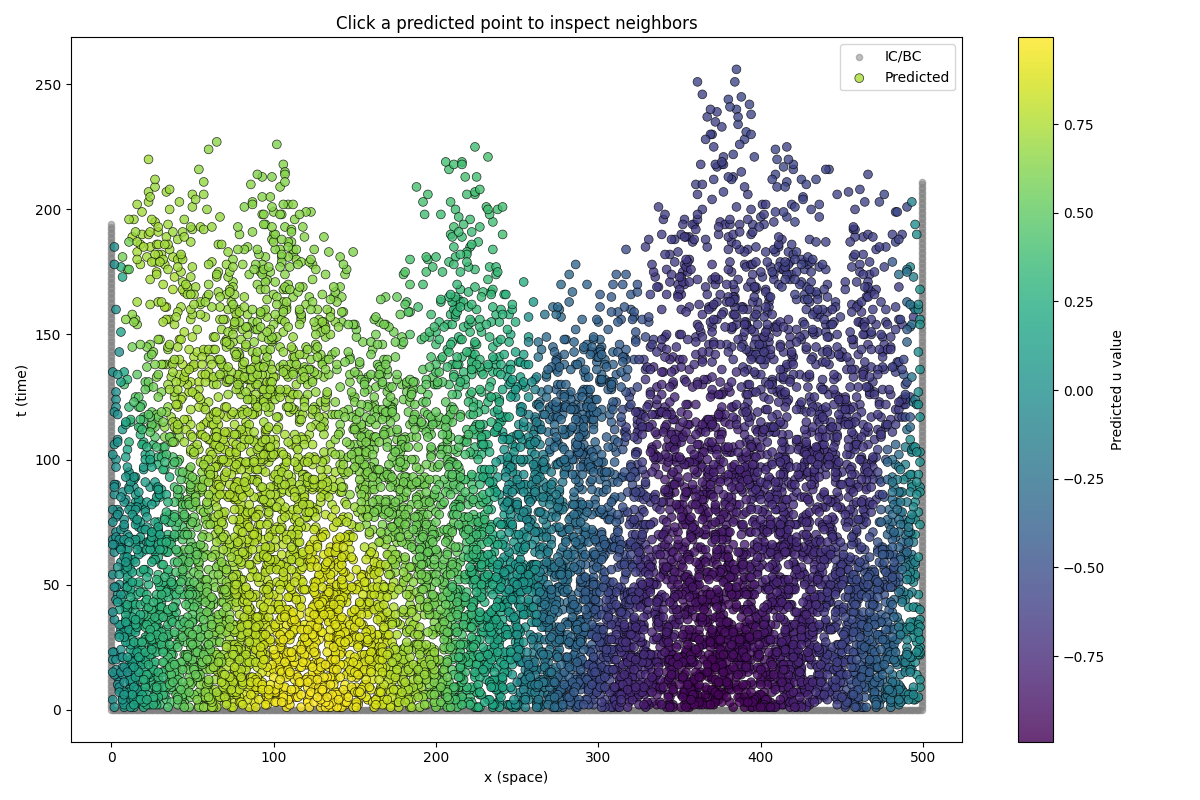


✓ Interactive plot ready — 10000 predicted, 905 IC/BC


(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Click a predicted point to inspect neighbors'}, xlabel='x (space)', ylabel='t (time)'>)

In [ ]:

# 3. Show interactive view
visualize_rollout_interactive(visited, u_values, history, data, config['R'], config)


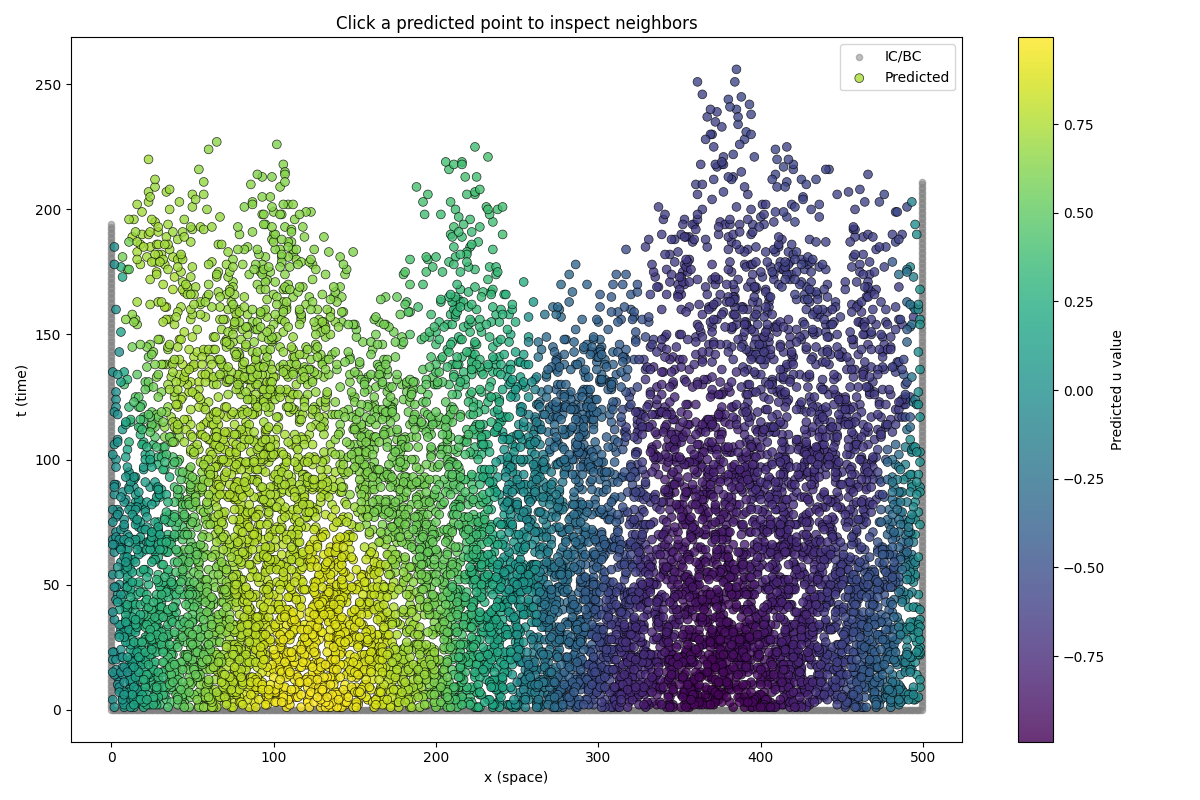


✓ Interactive plot ready — 10000 predicted, 905 IC/BC


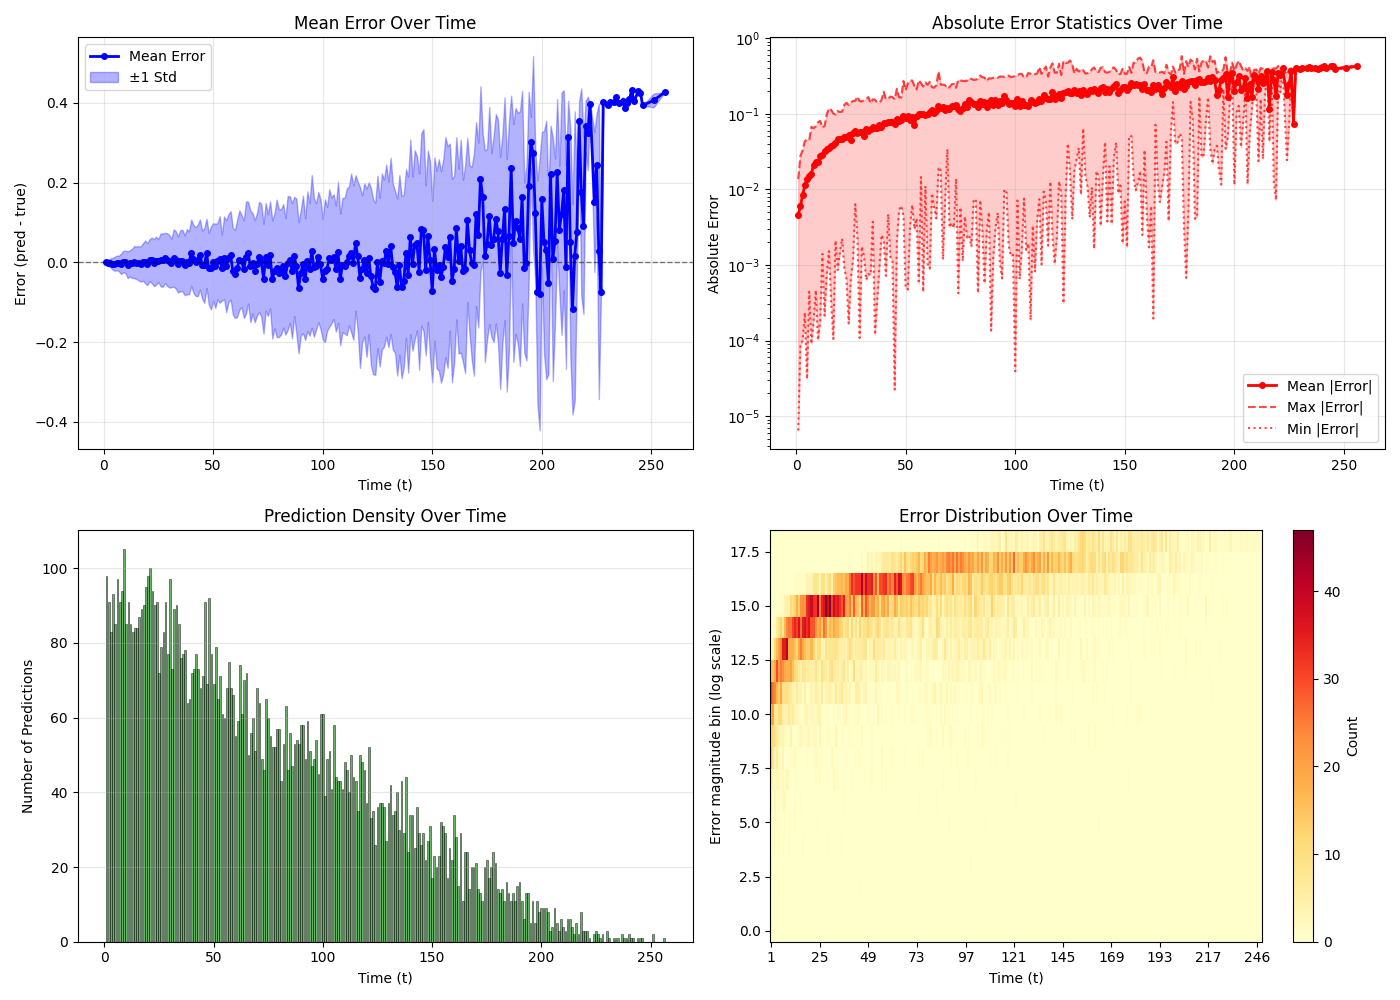


ERROR PROPAGATION SUMMARY
Total time steps with predictions: 243
Time range: t=1 to t=256

Overall Statistics:
  Mean error:   0.004098
  Std error:    0.151613
  Mean |error|: 0.113624
  Max  |error|: 0.579385
  RMSE:         0.151668

Error Trend:
  Mean |error| trend: increasing (slope: 1.36e-03 per time step)
  Early time (first 10%): mean |error| = 0.029402
  Late time  (last  10%): mean |error| = 0.369320



In [ ]:
fig, ax = visualize_rollout_interactive(visited, u_values, history, data, config['R'], config)
fig_err, axes_err = visualize_error_propagation(visited, u_values, history, data)
